# Exploratory Data Analysis — CarDekho Used Car Dataset

This notebook walks through a full EDA of the used-car dataset (`cardekho_imputated.csv`), covering:

1. Data loading & basic checks
2. Target variable (`selling_price`) analysis
3. Univariate analysis (numerical & categorical)
4. Bivariate analysis (features vs price)
5. Multivariate analysis (correlations)
6. Outlier detection
7. Feature engineering ideas
8. Key takeaways


## 1. Setup & Imports

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

pd.set_option("display.max_columns", None)


## 2. Load Data & Basic Checks

In [46]:
df = pd.read_csv("data/cardekho_imputated.csv")

# Drop the redundant index column that came with the CSV export
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print("Shape:", df.shape)
df.head()


Shape: (15411, 13)


,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


**What we're doing:** Loading the dataset and dropping the leftover index column. Next, let's check data types, missing values, and duplicates — this tells us how much cleaning is needed before analysis.

In [47]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15411 non-null  str    
 1   brand              15411 non-null  str    
 2   model              15411 non-null  str    
 3   vehicle_age        15411 non-null  int64  
 4   km_driven          15411 non-null  int64  
 5   seller_type        15411 non-null  str    
 6   fuel_type          15411 non-null  str    
 7   transmission_type  15411 non-null  str    
 8   mileage            15411 non-null  float64
 9   engine             15411 non-null  int64  
 10  max_power          15411 non-null  float64
 11  seats              15411 non-null  int64  
 12  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(5), str(6)
memory usage: 1.5 MB


In [48]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Missing values per column:
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Duplicate rows: 167


In [49]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
car_name,15411,121,Hyundai i20,906,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brand,15411,32,Maruti,4992,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,15411,120,i20,906,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vehicle_age,15411.0,NaN,NaN,NaN,6.036338,3.013291,0.0,4.0,6.0,8.0,29.0
km_driven,15411.0,NaN,NaN,NaN,55616.480631,51618.548422,100.0,30000.0,50000.0,70000.0,3800000.0
seller_type,15411,3,Dealer,9539,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fuel_type,15411,5,Petrol,7643,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission_type,15411,2,Manual,12225,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage,15411.0,NaN,NaN,NaN,19.701151,4.171265,4.0,17.0,19.67,22.7,33.54
engine,15411.0,NaN,NaN,NaN,1486.057751,521.106696,793.0,1197.0,1248.0,1582.0,6592.0


In [50]:
df.dtypes

car_name                 str
brand                    str
model                    str
vehicle_age            int64
km_driven              int64
seller_type              str
fuel_type                str
transmission_type        str
mileage              float64
engine                 int64
max_power            float64
seats                  int64
selling_price          int64
dtype: object

In [51]:
num_features = df.select_dtypes(include='number').columns.tolist()
print('Num of Numerical Features :', len(num_features))

cat_features = df.select_dtypes(exclude='number').columns.tolist()
print('Num of Categorical Features :', len(cat_features))


Num of Numerical Features : 7
Num of Categorical Features : 6


## 3. Categorical Column Overview

Checking how many unique values each categorical column has, and their distribution. This tells us if any column needs grouping (e.g. too many car models) before plotting.

In [52]:
cat_cols = ["brand", "model", "seller_type", "fuel_type", "transmission_type", "seats"]
for col in cat_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts().head(10))
    print()


--- brand ---
brand
Maruti        4992
Hyundai       2982
Honda         1485
Mahindra      1011
Toyota         793
Ford           790
Volkswagen     620
Renault        536
BMW            439
Tata           430
Name: count, dtype: int64

--- model ---
model
i20            906
Swift Dzire    890
Swift          781
Alto           778
City           757
Wagon R        717
Grand          580
Innova         545
Verna          492
i10            410
Name: count, dtype: int64

--- seller_type ---
seller_type
Dealer              9539
Individual          5699
Trustmark Dealer     173
Name: count, dtype: int64

--- fuel_type ---
fuel_type
Petrol      7643
Diesel      7419
CNG          301
LPG           44
Electric       4
Name: count, dtype: int64

--- transmission_type ---
transmission_type
Manual       12225
Automatic     3186
Name: count, dtype: int64

--- seats ---
seats
5    12910
7     1922
8      311
6      127
4       77
9       55
2        7
0        2
Name: count, dtype: int64



## 4. Target Variable: `selling_price`

Since `selling_price` is what we'd eventually predict, understanding its distribution is critical. Used-car prices are typically **right-skewed** — a large number of affordable cars and a long tail of expensive ones — so we check for skew and whether a log transform would help.

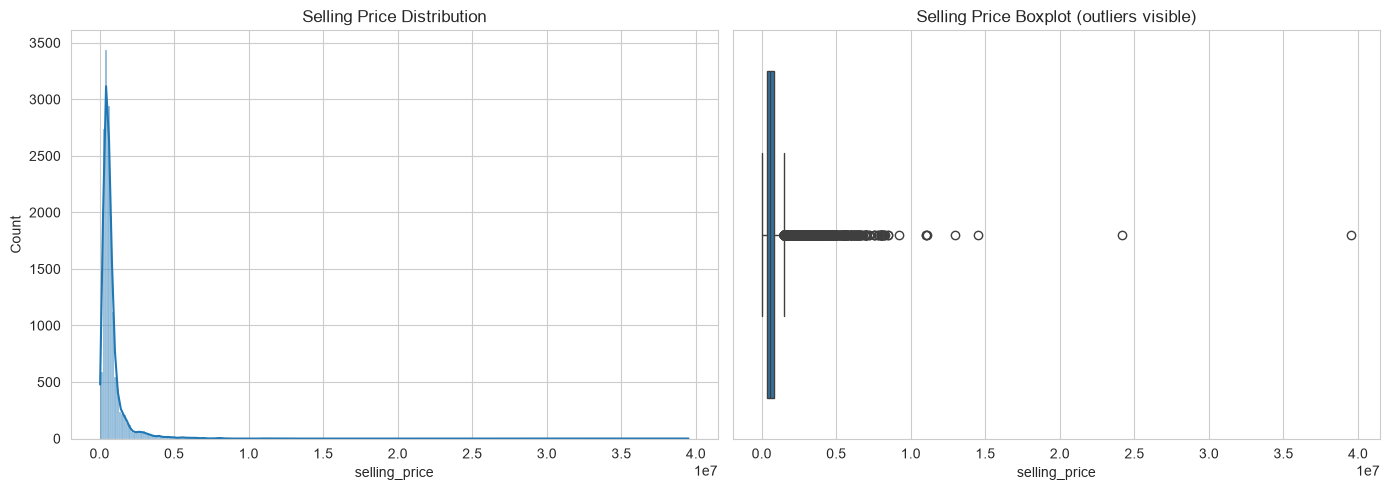

Skewness: 10.047047978435213


In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["selling_price"], kde=True, ax=axes[0])
axes[0].set_title("Selling Price Distribution")

sns.boxplot(x=df["selling_price"], ax=axes[1])
axes[1].set_title("Selling Price Boxplot (outliers visible)")

plt.tight_layout()
plt.show()

print("Skewness:", df["selling_price"].skew())


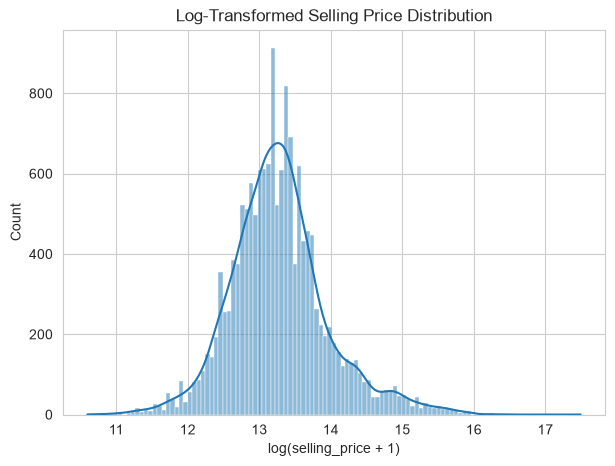

In [54]:
# Log-transformed view to check if it normalizes the distribution
plt.figure(figsize=(7, 5))
sns.histplot(np.log1p(df["selling_price"]), kde=True)
plt.title("Log-Transformed Selling Price Distribution")
plt.xlabel("log(selling_price + 1)")
plt.show()


## 5. Univariate Analysis — Numerical Features

Looking at the shape of each numeric feature individually: `vehicle_age`, `km_driven`, `mileage`, `engine`, `max_power`.

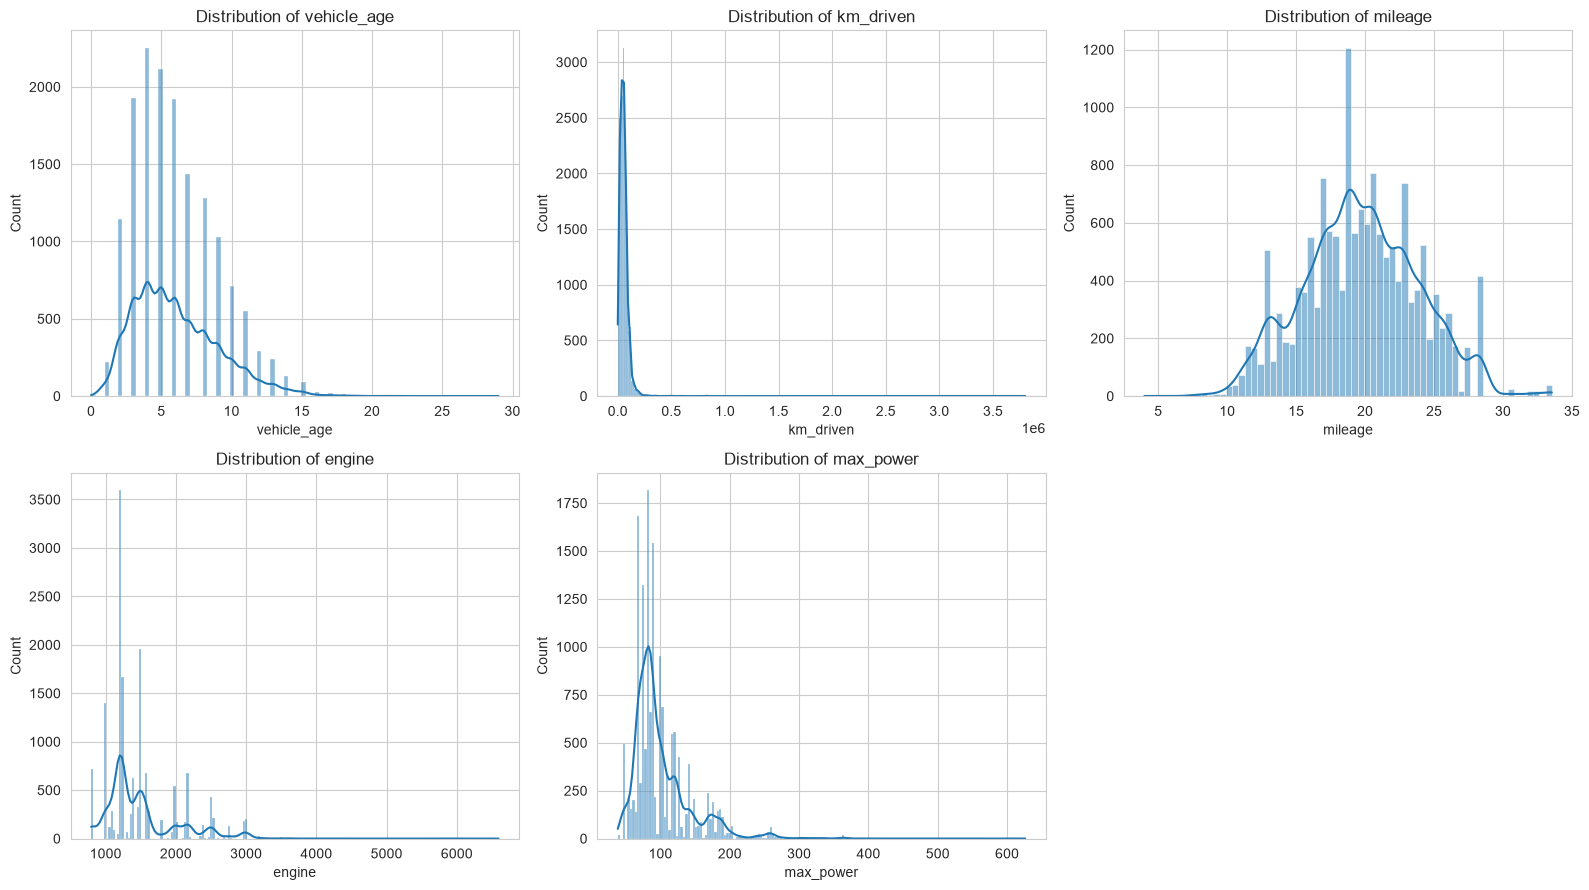

In [55]:
num_cols = ["vehicle_age", "km_driven", "mileage", "engine", "max_power"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")

# hide the unused 6th subplot
axes[-1].axis("off")
plt.tight_layout()
plt.show()


## 6. Univariate Analysis — Categorical Features

Count plots for `fuel_type`, `seller_type`, `transmission_type`, and the top 10 most common `brand`s.

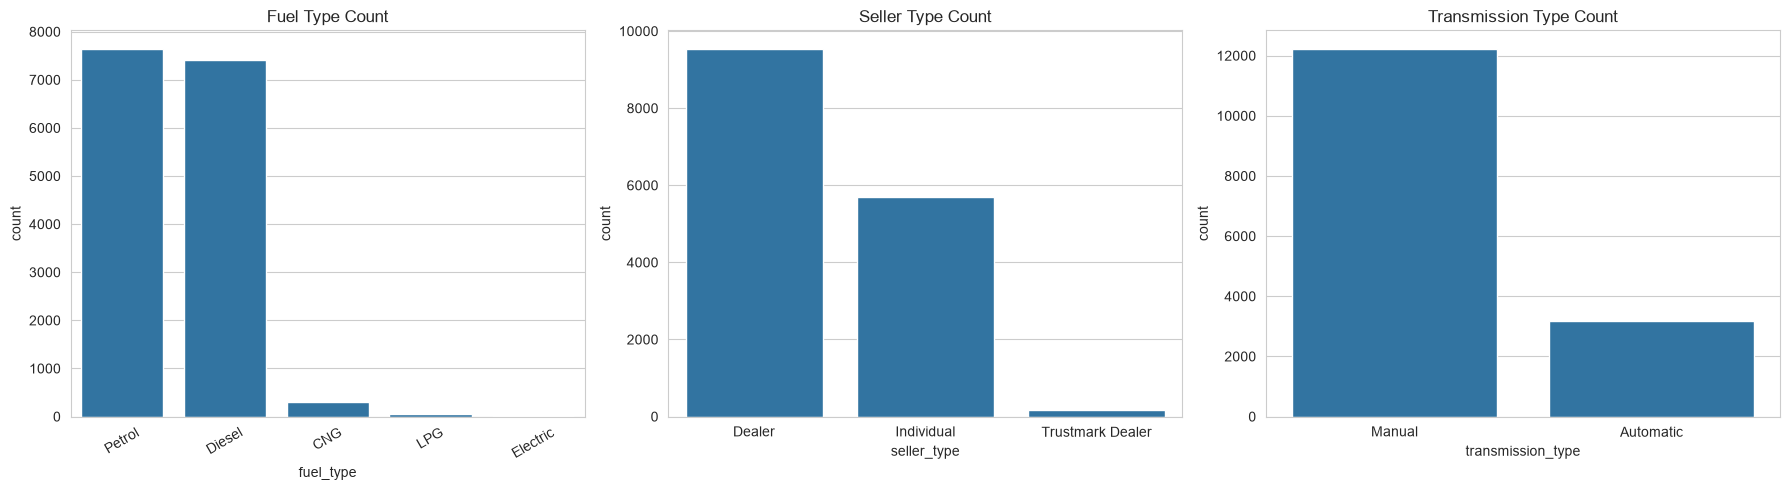

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x="fuel_type", ax=axes[0], order=df["fuel_type"].value_counts().index)
axes[0].set_title("Fuel Type Count")
axes[0].tick_params(axis="x", rotation=30)

sns.countplot(data=df, x="seller_type", ax=axes[1], order=df["seller_type"].value_counts().index)
axes[1].set_title("Seller Type Count")

sns.countplot(data=df, x="transmission_type", ax=axes[2], order=df["transmission_type"].value_counts().index)
axes[2].set_title("Transmission Type Count")

plt.tight_layout()
plt.show()


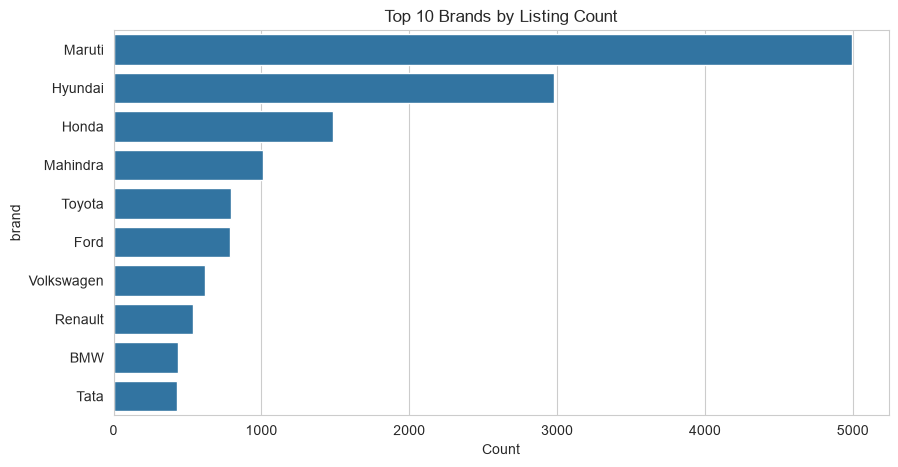

In [57]:
top_brands = df["brand"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_brands.values, y=top_brands.index, orient="h")
plt.title("Top 10 Brands by Listing Count")
plt.xlabel("Count")
plt.show()


## 7. Bivariate Analysis — Features vs `selling_price`

Now we check how each feature relates to price. Expectations going in:
- `vehicle_age` ↑ → price ↓
- `km_driven` ↑ → price ↓
- `max_power` / `engine` ↑ → price ↑
- Automatic transmission and Dealer-sold cars often command higher prices


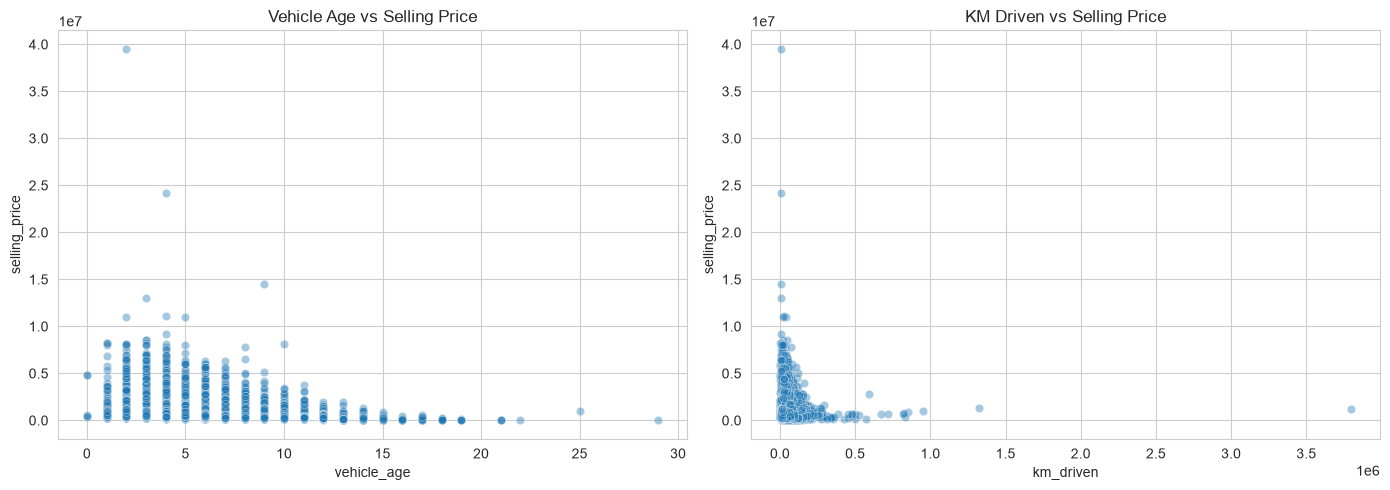

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x="vehicle_age", y="selling_price", alpha=0.4, ax=axes[0])
axes[0].set_title("Vehicle Age vs Selling Price")

sns.scatterplot(data=df, x="km_driven", y="selling_price", alpha=0.4, ax=axes[1])
axes[1].set_title("KM Driven vs Selling Price")

plt.tight_layout()
plt.show()


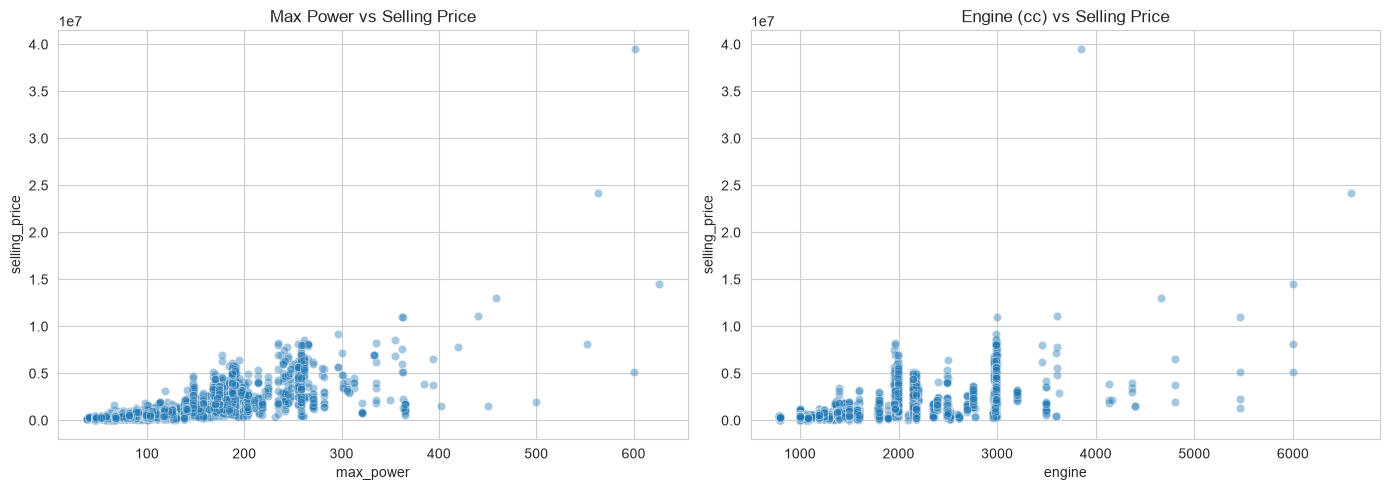

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x="max_power", y="selling_price", alpha=0.4, ax=axes[0])
axes[0].set_title("Max Power vs Selling Price")

sns.scatterplot(data=df, x="engine", y="selling_price", alpha=0.4, ax=axes[1])
axes[1].set_title("Engine (cc) vs Selling Price")

plt.tight_layout()
plt.show()


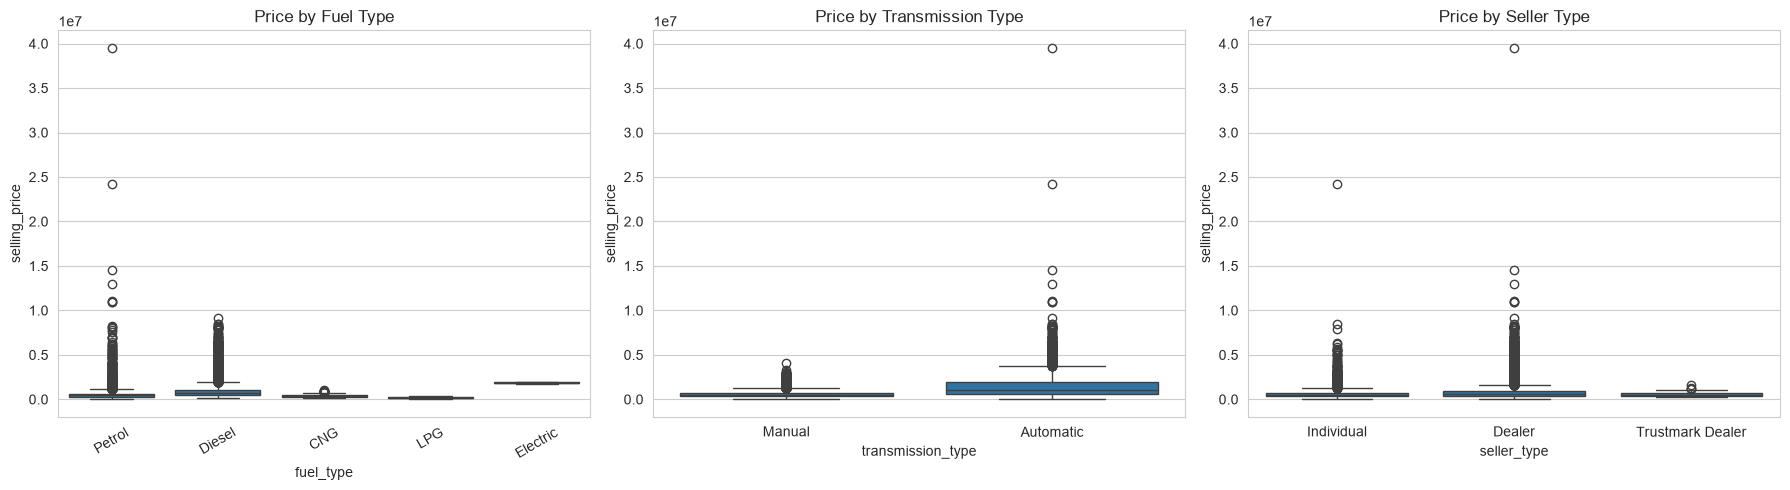

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x="fuel_type", y="selling_price", ax=axes[0])
axes[0].set_title("Price by Fuel Type")
axes[0].tick_params(axis="x", rotation=30)

sns.boxplot(data=df, x="transmission_type", y="selling_price", ax=axes[1])
axes[1].set_title("Price by Transmission Type")

sns.boxplot(data=df, x="seller_type", y="selling_price", ax=axes[2])
axes[2].set_title("Price by Seller Type")

plt.tight_layout()
plt.show()


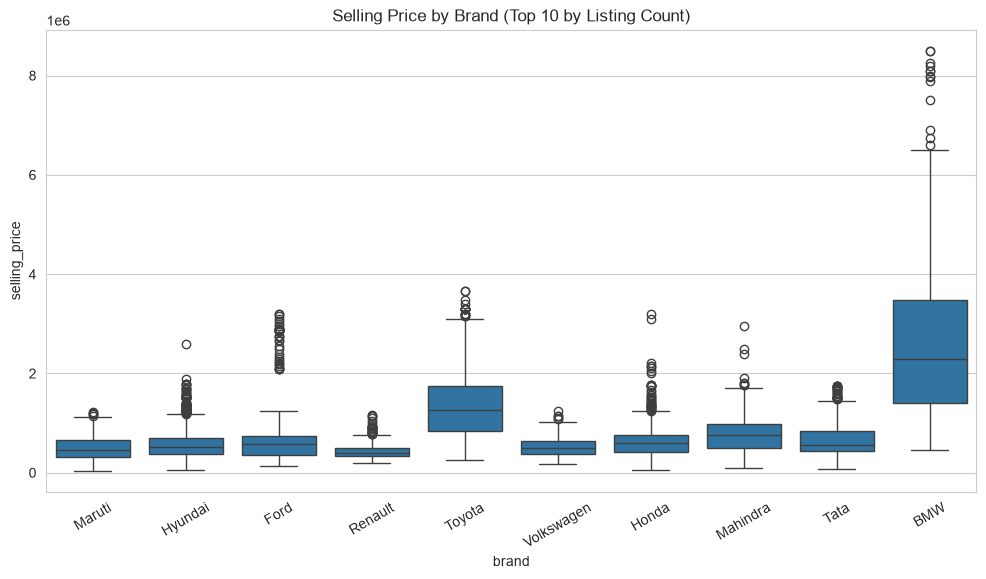

In [61]:
plt.figure(figsize=(12, 6))
top10_brand_names = df["brand"].value_counts().head(10).index
sns.boxplot(data=df[df["brand"].isin(top10_brand_names)], x="brand", y="selling_price")
plt.title("Selling Price by Brand (Top 10 by Listing Count)")
plt.xticks(rotation=30)
plt.show()


## 8. Multivariate Analysis — Correlation Heatmap & Pairplot

Checking correlations among numeric variables together, to spot multicollinearity (e.g. `engine` and `max_power` are often correlated) and confirm which features are most linearly related to `selling_price`.

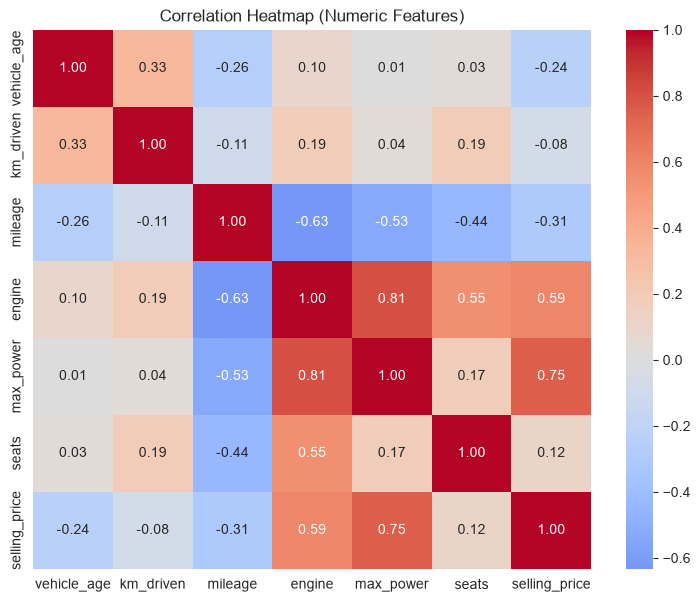

In [62]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(9, 7))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()


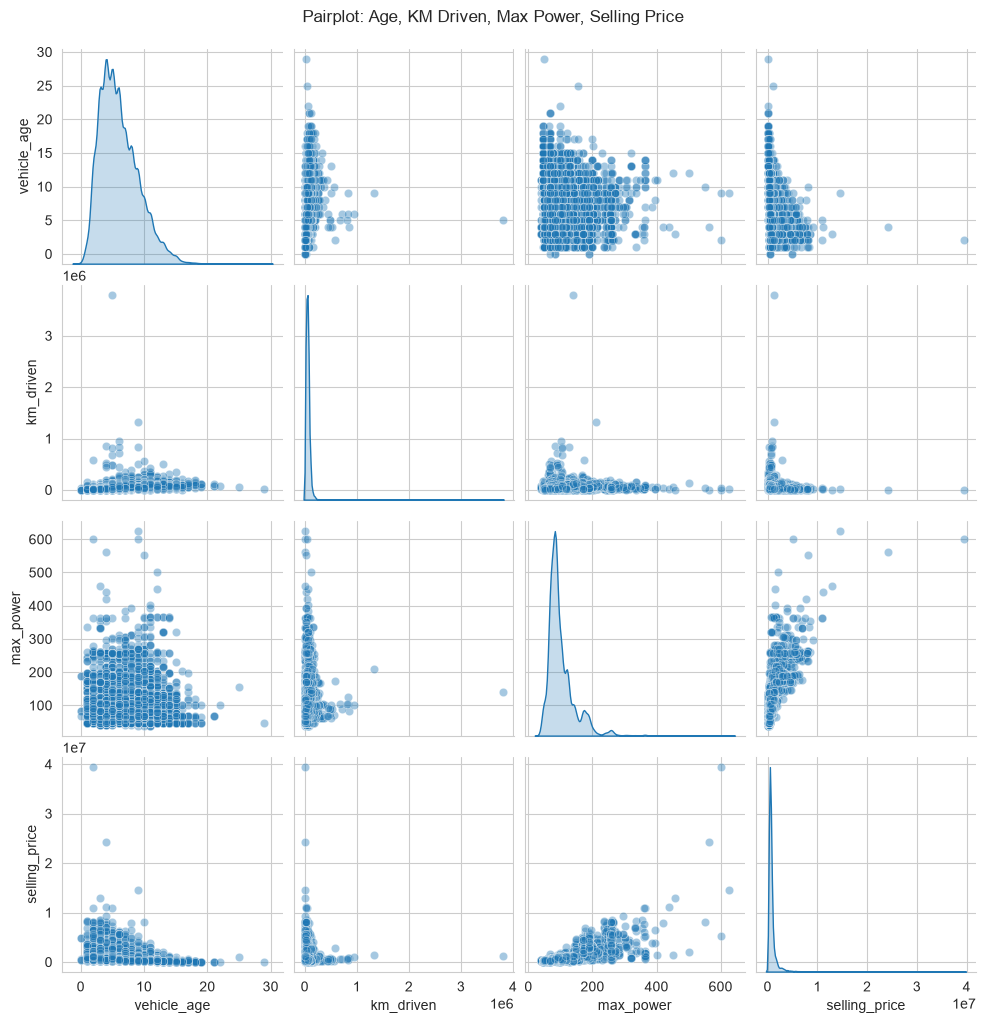

In [63]:
sns.pairplot(
    df[["vehicle_age", "km_driven", "max_power", "selling_price"]],
    diag_kind="kde",
    plot_kws={"alpha": 0.4}
)
plt.suptitle("Pairplot: Age, KM Driven, Max Power, Selling Price", y=1.02)
plt.show()


## 9. Outlier Detection

Using the IQR method to flag outliers in `km_driven` and `selling_price`, since both tend to have extreme high-end values in used-car datasets.

In [64]:
def iqr_outlier_summary(series, name):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = series[(series < lower) | (series > upper)]
    print(f"{name}: {len(outliers)} outliers "
          f"({len(outliers) / len(series) * 100:.2f}% of data) "
          f"| bounds = [{lower:,.0f}, {upper:,.0f}]")
    return outliers

_ = iqr_outlier_summary(df["km_driven"], "km_driven")
_ = iqr_outlier_summary(df["selling_price"], "selling_price")
_ = iqr_outlier_summary(df["max_power"], "max_power")


km_driven: 466 outliers (3.02% of data) | bounds = [-30,000, 130,000]
selling_price: 1386 outliers (8.99% of data) | bounds = [-275,000, 1,485,000]
max_power: 867 outliers (5.63% of data) | bounds = [9, 182]


## 10. Feature Engineering Ideas (Exploration)

A few derived features that might help a later modeling stage — computed here just to sanity-check they make sense.

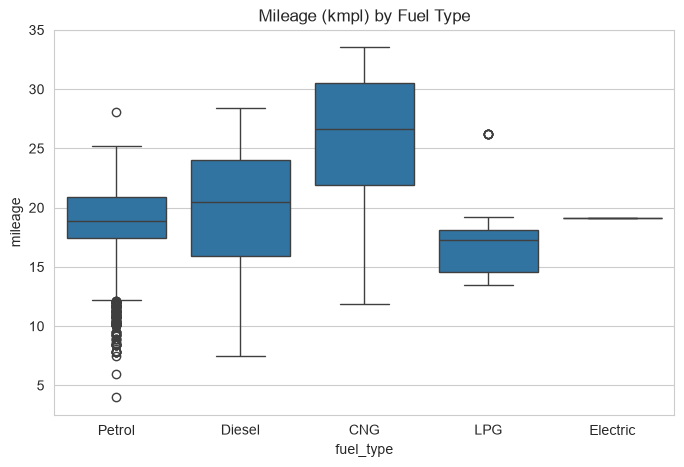

In [65]:
# Mileage comparison across fuel types
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="fuel_type", y="mileage")
plt.title("Mileage (kmpl) by Fuel Type")
plt.show()


In [66]:
# Rough "value" ratio: price per unit of max_power (higher = pricier for its power class)
df_fe = df.copy()
df_fe["price_per_power"] = df_fe["selling_price"] / df_fe["max_power"].replace(0, np.nan)

df_fe.groupby("brand")["price_per_power"].mean().sort_values(ascending=False).head(10)


brand
Ferrari         65723.793677
Rolls-Royce     42984.014210
Lexus           23382.202590
Maserati        22514.129158
Land Rover      18702.693953
Porsche         17953.097680
Volvo           17635.811916
Bentley         15501.173002
Mini            14655.867276
Mercedes-AMG    14085.674041
Name: price_per_power, dtype: float64

## 11. Key Takeaways (fill in after running)

- **Target variable:** `selling_price` is right-skewed — consider a log transform for modeling.
- **Strongest relationships:** `max_power` and `engine` tend to correlate positively with price; `vehicle_age` and `km_driven` tend to correlate negatively.
- **Categorical effects:** transmission type and seller type visibly shift the price distribution — check boxplots above for the direction and magnitude.
- **Outliers:** a small percentage of `km_driven` and `selling_price` values sit far outside the IQR bounds — decide whether to cap, remove, or keep them depending on your modeling goal.
- **Multicollinearity:** `engine` and `max_power` are likely correlated — watch for this if you move to linear regression.

*(Update this section with the actual numbers/insights once you run the notebook.)*
